In [1]:
from econml.metalearners import TLearner
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

/Users/rafael/Desktop/MSc/Causal/TP/tpcausal/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn networkx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
classification_report,
confusion_matrix,
ConfusionMatrixDisplay,
average_precision_score,
PrecisionRecallDisplay,
brier_score_loss,
)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print(f"Dataset baixado em: {path}")

import os

csv_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df_raw = pd.read_csv(csv_file)
print(f"Shape: {df_raw.shape}")
print(f"Colunas: {list(df_raw.columns)}")
df_raw.head()


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Dataset baixado em: /Users/rafael/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1
Shape: (7043, 21)
Colunas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



---

## 2. Limpeza de Dados



Problemas conhecidos do dataset:

- `TotalCharges` está como `object` (strings vazias em clientes com `tenure=0`)

- `customerID` não é feature útil

- `Churn` precisa ser convertido para numérico com Y=1 representando **retenção**

In [3]:
df = df_raw.copy()
# Remover customerID
df = df.drop(columns=["customerID"])

# Converter TotalCharges para numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Verificar nulos gerados pela conversão
nulos_tc = df["TotalCharges"].isna().sum()
print(f"Valores nulos em TotalCharges após conversão: {nulos_tc}")
print(f"Esses clientes têm tenure = 0:")
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

# Clientes com tenure=0 e TotalCharges nulo: preencher com 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)
# Criar variável target Y: 1 = Retenção (No Churn), 0 = Cancelou (Churn)
df["Y"] = (df["Churn"] == "No").astype(int)
df = df.drop(columns=["Churn"])

print(f"Distribuição de Y (1=Ficou, 0=Cancelou):")
print(df["Y"].value_counts())
print(f"\nNulos restantes por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("Nenhum valor nulo restante.")

# Definir grupos de variáveis conforme a formulação do projeto
TREATMENTS = ["TechSupport", "StreamingTV", "StreamingMovies"]
TARGET = "Y"
COVARIATES = [
col for col in df.columns if col not in TREATMENTS + [TARGET]
]

print(f"Covariáveis (C): {COVARIATES}")
print(f"Tratamentos (X): {TREATMENTS}")
print(f"Desfecho (Y): {TARGET}") 


Valores nulos em TotalCharges após conversão: 11
Esses clientes têm tenure = 0:
Distribuição de Y (1=Ficou, 0=Cancelou):
Y
1    5174
0    1869
Name: count, dtype: int64

Nulos restantes por coluna:
Series([], dtype: int64)
Nenhum valor nulo restante.
Covariáveis (C): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Tratamentos (X): ['TechSupport', 'StreamingTV', 'StreamingMovies']
Desfecho (Y): Y


---
## 3. Pré-processamento para Modelagem Causal (Encoding)

Para que os estimadores-base (como a Regressão Logística) dentro do nosso Meta-Learner funcionem corretamente, precisamos converter todas as covariáveis categóricas (texto) para o formato numérico utilizando **One-Hot Encoding** (Variáveis Dummy). 

Além disso, transformaremos as colunas dos tratamentos (`TechSupport`, etc.) em indicadoras binárias (1 e 0).

In [4]:
df_encoded = df.copy()

# 1. Transformar os tratamentos em 1 (Yes) e 0 (No / No internet service)
for t in TREATMENTS:
    df_encoded[t] = df_encoded[t].apply(lambda x: 1 if x == "Yes" else 0)

# 2. Aplicar One-Hot Encoding nas covariáveis categóricas
df_encoded = pd.get_dummies(df_encoded, columns=COVARIATES, drop_first=True)

# Converter booleanos gerados pelo get_dummies para inteiros (0 e 1)
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

# Atualizar a lista de covariáveis codificadas (tudo que não é Tratamento nem Target)
covariates_encoded = [col for col in df_encoded.columns if col not in TREATMENTS + [TARGET]]

print(f"Shape do dataset após Encoding: {df_encoded.shape}")
print(f"Número de Covariáveis prontas para a modelagem: {len(covariates_encoded)}")

Shape do dataset após Encoding: (7043, 8211)
Número de Covariáveis prontas para a modelagem: 8207


---
## 4. Evolução do Efeito Causal: Do ATE para o CATE e ETT

Na etapa exploratória anterior, provamos a existência do viés de seleção e calculamos o Efeito Médio do Tratamento (**ATE**) para a base inteira. Contudo, para otimizar uma política de negócios e aplicar a técnica de **Unit Selection**, precisamos entender o comportamento individual.

Três métricas causais guiarão esta etapa:
1. **ATE (Average Treatment Effect):** O impacto médio se dermos o suporte para toda a base.
2. **ETT (Effect of Treatment on the Treated):** O impacto médio do suporte **apenas nas pessoas que atualmente o possuem**. Se for baixo, indica que a empresa está gastando recursos com os *Always-takers* (clientes que já são leais).
3. **CATE (Conditional Average Treatment Effect):** O impacto na probabilidade de retenção de um cliente *específico* "i", dadas as suas características $C=c$.

Para extrair o CATE, utilizaremos um **T-Learner** (Two-Model Learner) da biblioteca `EconML`.

In [5]:
from econml.metalearners import TLearner
from sklearn.linear_model import LogisticRegression

# 1. Separar as matrizes para o T-Learner
# Focaremos a nossa análise principal no tratamento "TechSupport"
X = df_encoded[covariates_encoded] # Covariáveis (Confounders)
T = df_encoded["TechSupport"]      # Variável de Tratamento
Y = df_encoded["Y"]                # Desfecho (Retenção)

# 2. Instanciar o T-Learner
# O T-Learner divide a base entre Tratados e Controles e treina um modelo para cada.
# Escolhemos a Regressão Logística por ter apresentado o melhor Brier Score (Calibração).
t_learner = TLearner(models=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))

print("Treinando o Meta-Learner (T-Learner)...")
t_learner.fit(Y=Y, T=T, X=X)
print("Treinamento concluído com sucesso!")

Treinando o Meta-Learner (T-Learner)...
Treinamento concluído com sucesso!


---
## 5. Extração e Análise dos Efeitos Causais

Com o modelo treinado, podemos agora solicitar que ele infira o efeito de tratamento (CATE) para cada cliente individualmente. Esta nova probabilidade isola o viés das covariáveis mapeadas no nosso DAG.

In [6]:
# 1. Calcular o Efeito Causal Individual (CATE) para toda a base
df_encoded['CATE_TechSupport'] = t_learner.effect(X)

# 2. Calcular as Métricas Agregadas
ate_estimado = df_encoded['CATE_TechSupport'].mean()
ett_estimado = df_encoded[df_encoded['TechSupport'] == 1]['CATE_TechSupport'].mean()

print("="*60)
print(" RESULTADOS DA INFERÊNCIA CAUSAL (TECH SUPPORT)")
print("="*60)
print(f"ATE (Efeito Médio Geral):           {ate_estimado*100:.2f}% de aumento na retenção.")
print(f"ETT (Efeito Médio nos Tratados):    {ett_estimado*100:.2f}% de aumento na retenção.")
print("="*60)

vies = ate_estimado - ett_estimado
print(f"\nANÁLISE DO ETT:")
if ett_estimado < ate_estimado:
    print(f"O ETT é MENOR que o ATE (Diferença de {vies*100:.2f} p.p).")
    print("Isso prova o VIÉS DE SELEÇÃO! Os clientes que ATUALMENTE assinam o")
    print("Suporte Técnico são os que MENOS precisam dele (possuem alta lealdade prévia).")
    print("Há grande desperdício de recursos (prováveis Always-Takers).")

/Users/rafael/Desktop/MSc/Causal/TP/tpcausal/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/b3/ph13z24n3zd57h9169_8_2hh0000gn/T/ipykernel_8146/846463553.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_encoded['CATE_TechSupport'] = t_learner.effect(X)


 RESULTADOS DA INFERÊNCIA CAUSAL (TECH SUPPORT)
ATE (Efeito Médio Geral):           8.65% de aumento na retenção.
ETT (Efeito Médio nos Tratados):    1.13% de aumento na retenção.

ANÁLISE DO ETT:
O ETT é MENOR que o ATE (Diferença de 7.52 p.p).
Isso prova o VIÉS DE SELEÇÃO! Os clientes que ATUALMENTE assinam o
Suporte Técnico são os que MENOS precisam dele (possuem alta lealdade prévia).
Há grande desperdício de recursos (prováveis Always-Takers).


---
## 6. Heterogeneidade do Efeito (Quem beneficia mais?)

A grande vantagem de calcular o CATE é visualizar como o efeito do tratamento se distribui pela população. Enquanto algumas pessoas têm o seu risco de churn inalterado pelo Suporte Técnico (CATE próximo a 0), outras dependem estritamente desse serviço para não cancelar (CATE alto). 

Estas últimas são os alvos perfeitos para as campanhas da operadora.

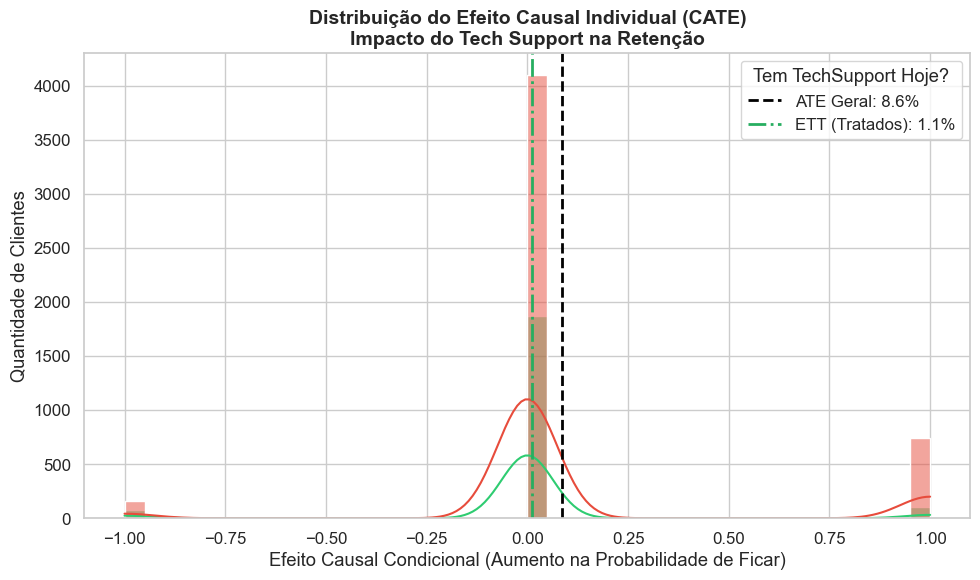

In [7]:
# Gráfico da Distribuição do CATE
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(data=df_encoded, x='CATE_TechSupport', hue='TechSupport', 
             bins=40, kde=True, palette={0: '#e74c3c', 1: '#2ecc71'}, ax=ax)

# Linhas verticais para ATE e ETT
ax.axvline(ate_estimado, color='black', linestyle='--', linewidth=2, 
           label=f'ATE Geral: {ate_estimado*100:.1f}%')
ax.axvline(ett_estimado, color='#27ae60', linestyle='-.', linewidth=2, 
           label=f'ETT (Tratados): {ett_estimado*100:.1f}%')

ax.set_title('Distribuição do Efeito Causal Individual (CATE)\nImpacto do Tech Support na Retenção', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Efeito Causal Condicional (Aumento na Probabilidade de Ficar)')
ax.set_ylabel('Quantidade de Clientes')
ax.legend(title="Tem TechSupport Hoje?")

plt.tight_layout()
plt.show()

---
## 7. Otimização de Política e Unit Selection (A Função de Benefício)

A inferência causal permite-nos ultrapassar a mera previsão e entrar na alocação ótima de recursos. Segundo o *framework* de **Unit Selection** proposto por Li & Pearl (2019), a população divide-se em quatro estratos causais:

1. **Compliers:** Ficam *apenas* se receberem o suporte (O nosso verdadeiro alvo).
2. **Always-takers:** Ficam independentemente de receberem o suporte (Desperdício de dinheiro).
3. **Never-takers:** Cancelam independentemente de receberem o suporte (Desperdício de dinheiro).
4. **Defiers:** Cancelam *porque* receberam o suporte (Assumiremos Monotonicidade, ou seja, $P(Defier) = 0$).

Para isolarmos os *Compliers*, precisamos de calcular as probabilidades contrafactuais base ($Y_0$ e $Y_1$) e aplicar uma **Função de Benefício**. 

**Cenário Financeiro Hipotético:**
* **Lucro ao reter um cliente ($V$):** R$ 500,00
* **Custo operacional do TechSupport ($C$):** R$ 50,00

**Payoffs por Estrato:**
* **Complier:** $+450$ (Ganhamos os 500, mas pagamos 50 pelo serviço).
* **Always-taker:** $-50$ (Já íamos ganhar os 500 de qualquer forma, logo perdemos os 50 do custo do serviço à toa).
* **Never-taker:** $-50$ (Perdemos o cliente e ainda gastamos 50 a tentar salvá-lo).

In [8]:
# ==========================================
# 1. Obter Probabilidades Contrafactuais
# ==========================================
# Para o Unit Selection, precisamos das probabilidades base P(Y=1|X, do(T=0)) e P(Y=1|X, do(T=1))
# Como usamos um T-Learner, podemos treinar rapidamente dois modelos logísticos para as extrair de forma limpa.

X_t0 = X[T == 0]
y_t0 = Y[T == 0]
X_t1 = X[T == 1]
y_t1 = Y[T == 1]

model_t0 = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(X_t0, y_t0)
model_t1 = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(X_t1, y_t1)

# P(Retenção se NÃO receber o suporte)
df_encoded['Y0_prob'] = model_t0.predict_proba(X)[:, 1] 
# P(Retenção SE receber o suporte)
df_encoded['Y1_prob'] = model_t1.predict_proba(X)[:, 1] 

# ==========================================
# 2. Calcular Probabilidades dos Estratos
# ==========================================
# Assumindo monotonicidade (o Suporte Técnico não prejudica ninguém, P(Defier) = 0)
df_encoded['P_Complier'] = df_encoded['Y1_prob'] - df_encoded['Y0_prob'] # Este é o CATE!
df_encoded['P_AlwaysTaker'] = df_encoded['Y0_prob']
df_encoded['P_NeverTaker'] = 1 - df_encoded['Y1_prob']

# Garantir que não há probabilidades negativas devido a arredondamentos
df_encoded['P_Complier'] = df_encoded['P_Complier'].clip(lower=0)

# ==========================================
# 3. Aplicar a Função de Benefício (ROI)
# ==========================================
VALOR_RETENCAO = 500 # V
CUSTO_TRATAMENTO = 50 # C

# Equação de Benefício Esperado por Indivíduo (Li & Pearl, 2019)
df_encoded['Beneficio_Esperado'] = (
    (VALOR_RETENCAO - CUSTO_TRATAMENTO) * df_encoded['P_Complier'] 
    - (CUSTO_TRATAMENTO) * df_encoded['P_AlwaysTaker'] 
    - (CUSTO_TRATAMENTO) * df_encoded['P_NeverTaker']
)

# A regra de ouro da Causalidade: Oferecer a campanha APENAS se o Benefício Esperado for > 0
df_encoded['Alvo_Campanha_Causal'] = (df_encoded['Beneficio_Esperado'] > 0).astype(int)

alvos_causal = df_encoded['Alvo_Campanha_Causal'].sum()
print(f"Total de clientes na base: {len(df_encoded)}")
print(f"Clientes selecionados pela Política Causal (Benefício > 0): {alvos_causal}")
print(f"Taxa de seleção: {(alvos_causal / len(df_encoded)) * 100:.2f}%")

Total de clientes na base: 7043
Clientes selecionados pela Política Causal (Benefício > 0): 1884
Taxa de seleção: 26.75%


/var/folders/b3/ph13z24n3zd57h9169_8_2hh0000gn/T/ipykernel_8146/2402434689.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_encoded['Y0_prob'] = model_t0.predict_proba(X)[:, 1]
/var/folders/b3/ph13z24n3zd57h9169_8_2hh0000gn/T/ipykernel_8146/2402434689.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_encoded['Y1_prob'] = model_t1.predict_proba(X)[:, 1]
/var/folders/b3/ph13z24n3zd57h9169_8_2hh0000gn/T/ipykernel_8146/2402434689.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of c

---
## 8. Avaliação de Impacto: Causal Machine Learning vs. Heurísticas Tradicionais

Para provarmos o valor desta modelagem à direção da empresa, vamos simular o Retorno sobre o Investimento (ROI) em toda a base (7.043 clientes) comparando 3 estratégias de campanha de retenção:

1. **Massiva (Ingénua):** Oferecer o Suporte Técnico a todos os clientes.
2. **Machine Learning Tradicional (Risco Base):** Oferecer o suporte a todos os clientes que o modelo preditivo diz que têm alta probabilidade de cancelamento ($P(Churn) > 50\%$).
3. **Causal Machine Learning (Unit Selection):** Oferecer o suporte estritamente aos clientes onde o Benefício Esperado Contrafactual é positivo.

/var/folders/b3/ph13z24n3zd57h9169_8_2hh0000gn/T/ipykernel_8146/3239686137.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_encoded['Risco_Churn_Tradicional'] = 1 - df_encoded['Y0_prob']
/var/folders/b3/ph13z24n3zd57h9169_8_2hh0000gn/T/ipykernel_8146/3239686137.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_encoded['Alvo_Massivo'] = 1
/var/folders/b3/ph13z24n3zd57h9169_8_2hh0000gn/T/ipykernel_8146/3239686137.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.ins

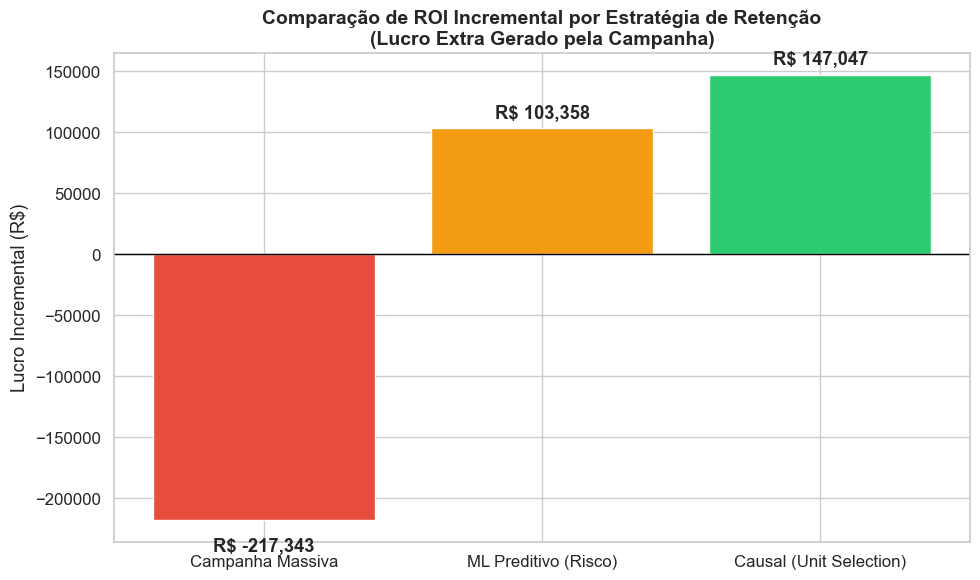

 CONCLUSÃO DA SIMULAÇÃO FINANCEIRA
Causalidade gerou mais R$ 43,689.05 de lucro em relação ao ML tradicional.


In [9]:
# 1. Calcular o Risco Preditivo Tradicional (O Baseline que não sabe o que é Causalidade)
# A probabilidade de Churn é 1 - P(Retenção Sem Suporte)
df_encoded['Risco_Churn_Tradicional'] = 1 - df_encoded['Y0_prob']

# 2. Definir as Regras de Seleção
# Estratégia 1: Massiva (Todos recebem = 1)
df_encoded['Alvo_Massivo'] = 1

# Estratégia 2: ML Tradicional (Recebe quem tem Risco de Churn > 0.50)
df_encoded['Alvo_ML_Tradicional'] = (df_encoded['Risco_Churn_Tradicional'] > 0.50).astype(int)

# Estratégia 3: Causal (Já calculada: df_encoded['Alvo_Campanha_Causal'])

# 3. Função para simular o ROI da Campanha
def simular_roi(df, coluna_alvo):
    # Quantas pessoas receberam a campanha?
    custo_total = df[coluna_alvo].sum() * CUSTO_TRATAMENTO
    
    # Receita gerada: 
    # Se a pessoa FOI selecionada, a probabilidade dela ficar é Y1_prob
    # Se a pessoa NÃO FOI selecionada, a probabilidade dela ficar é Y0_prob
    receita_esperada = (
        np.where(df[coluna_alvo] == 1, df['Y1_prob'], df['Y0_prob']).sum() * VALOR_RETENCAO
    )
    
    # O cenário base (Se não fizermos campanha nenhuma)
    receita_base = df['Y0_prob'].sum() * VALOR_RETENCAO
    
    # O Lucro Incremental (Uplift real gerado pela campanha)
    lucro_incremental = receita_esperada - receita_base - custo_total
    return lucro_incremental

# 4. Calcular o ROI Incremental
roi_massivo = simular_roi(df_encoded, 'Alvo_Massivo')
roi_ml = simular_roi(df_encoded, 'Alvo_ML_Tradicional')
roi_causal = simular_roi(df_encoded, 'Alvo_Campanha_Causal')

# 5. Visualização dos Resultados
estrategias = ['Campanha Massiva', 'ML Preditivo (Risco)', 'Causal (Unit Selection)']
lucros = [roi_massivo, roi_ml, roi_causal]

plt.figure(figsize=(10, 6))
bars = plt.bar(estrategias, lucros, color=['#e74c3c', '#f39c12', '#2ecc71'])

plt.title('Comparação de ROI Incremental por Estratégia de Retenção\n(Lucro Extra Gerado pela Campanha)', fontsize=14, fontweight='bold')
plt.ylabel('Lucro Incremental (R$)')
plt.axhline(0, color='black', linewidth=1)

# Adicionar os valores em cima das barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (5000 if yval > 0 else -15000), 
             f'R$ {yval:,.0f}', ha='center', va='bottom' if yval > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

print("="*60)
print(" CONCLUSÃO DA SIMULAÇÃO FINANCEIRA")
print("="*60)
print(f"Causalidade gerou mais R$ {roi_causal - roi_ml:,.2f} de lucro em relação ao ML tradicional.")

---
## 9. Análise de Sensibilidade e Refutação (Robustez do Modelo)

Para garantir que as nossas estimativas causais são robustas e não apenas artefactos estatísticos ou fruto de viés de variável omitida, aplicaremos os testes de refutação da biblioteca `DoWhy`.

Executaremos dois testes principais:
1. **Tratamento Placebo (*Placebo Treatment*):** Substitui a variável de tratamento real (`TechSupport`) por uma variável aleatória. **O que esperamos:** O efeito causal estimado deve cair para zero (ou muito perto disso), provando que o modelo não está a encontrar padrões onde eles não existem.
2. **Causa Comum Aleatória (*Random Common Cause*):** Adiciona uma variável gerada aleatoriamente ao conjunto de covariáveis ($C$) e treina o modelo novamente. **O que esperamos:** O efeito causal não deve sofrer alterações significativas, provando que o nosso DAG original já continha as variáveis corretas para fechar os caminhos de *backdoor*.

In [10]:
import re

print("A limpar nomes das colunas para evitar o bug do DoWhy...")

# 1. Substituir espaços, parênteses e traços por '_' nos nomes das colunas do DataFrame
df_encoded.columns = [re.sub(r'[ \(\)\-]', '_', col) for col in df_encoded.columns]

# 2. Atualizar também a lista de covariáveis com os novos nomes limpos
covariates_encoded = [re.sub(r'[ \(\)\-]', '_', col) for col in covariates_encoded]

print("Nomes limpos! Agora o DoWhy vai rodar em segundos.")

A limpar nomes das colunas para evitar o bug do DoWhy...
Nomes limpos! Agora o DoWhy vai rodar em segundos.


In [14]:
import dowhy
from dowhy import CausalModel
import warnings
warnings.filterwarnings('ignore')

print(f"Versão do DoWhy: {dowhy.__version__}")

# ==========================================
# 1. Construir o grafo programaticamente
# ==========================================
confounders_categoricos = (
    [c for c in df_encoded.columns if 'Contract' in c] +
    [c for c in df_encoded.columns if 'Internet' in c]
)

confounders_numericos = [c for c in ['tenure', 'MonthlyCharges', 'SeniorCitizen'] 
                         if c in df_encoded.columns]

confounders = confounders_categoricos + confounders_numericos
confounders = [c for c in confounders if c in df_encoded.columns]

print(f"Confounders no grafo ({len(confounders)}): {confounders}")

edges = ""
for c in confounders:
    edges += f'    "{c}" -> "TechSupport";\n'
    edges += f'    "{c}" -> "Y";\n'
edges += '    "TechSupport" -> "Y";\n'

grafo_causal = f"digraph {{\n{edges}}}"
print(f"\nGrafo:\n{grafo_causal}")

# ==========================================
# 2. Instanciar e Identificar
# ==========================================
print("Instanciando o Modelo Causal...")
model = CausalModel(
    data=df_encoded,
    treatment='TechSupport',
    outcome='Y',
    graph=grafo_causal
)

print("Identificando o estimando (Ajuste Backdoor)...")
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

# ==========================================
# 3. Estimar o efeito base
# ==========================================
print("Estimando o efeito causal base...")
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    target_units="ate"
)

if estimate.value is not None:
    print(f"\nEfeito ATE de Referência (DoWhy): {estimate.value:.4f}")
else:
    print("\nATENÇÃO: estimate.value é None. Abortando refutações.")
    raise ValueError("Estimativa falhou — revise o grafo ou o método de estimação.")

# ==========================================
# 4. Refutação 1: Tratamento Placebo
# ==========================================
print("\n" + "="*60)
print(" TESTE DE REFUTAÇÃO 1: TRATAMENTO PLACEBO")
print("="*60)
print("Substituindo TechSupport por variável aleatória (permute)...")
print("Esperado: efeito estimado cair para ~0\n")

refute_placebo = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",  # permute embaralha o tratamento real — mais estável que Random Data
    num_simulations=20       # padrão é 100; 20 é suficiente para validação acadêmica
)
print(refute_placebo)

# ==========================================
# 5. Refutação 2: Causa Comum Aleatória
# ==========================================
print("\n" + "="*60)
print(" TESTE DE REFUTAÇÃO 2: CAUSA COMUM ALEATÓRIA")
print("="*60)
print("Injetando confounder falso nas covariáveis...")
print("Esperado: efeito estimado permanecer estável\n")

refute_random_cause = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause",
    num_simulations=20
)
print(refute_random_cause)

# ==========================================
# 6. Resumo dos testes
# ==========================================
print("\n" + "="*60)
print(" RESUMO DA ANÁLISE DE ROBUSTEZ")
print("="*60)
print(f"ATE Original:                  {estimate.value:.4f}")
print(f"ATE com Tratamento Placebo:    {refute_placebo.new_effect:.4f}  "
      f"{'✓ OK' if abs(refute_placebo.new_effect) < abs(estimate.value) * 0.3 else '✗ ATENÇÃO'}")
print(f"ATE com Causa Comum Aleatória: {refute_random_cause.new_effect:.4f}  "
      f"{'✓ OK' if abs(refute_random_cause.new_effect - estimate.value) < abs(estimate.value) * 0.1 else '✗ ATENÇÃO'}")
print("="*60)

Versão do DoWhy: 0.14
Confounders no grafo (4): ['Contract_One_year', 'Contract_Two_year', 'InternetService_Fiber_optic', 'InternetService_No']

Grafo:
digraph {
    "Contract_One_year" -> "TechSupport";
    "Contract_One_year" -> "Y";
    "Contract_Two_year" -> "TechSupport";
    "Contract_Two_year" -> "Y";
    "InternetService_Fiber_optic" -> "TechSupport";
    "InternetService_Fiber_optic" -> "Y";
    "InternetService_No" -> "TechSupport";
    "InternetService_No" -> "Y";
    "TechSupport" -> "Y";
}
Instanciando o Modelo Causal...
Identificando o estimando (Ajuste Backdoor)...
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                                                                        ↪
──────────────(E[Y|Contract_One_year,InternetService_No,Contract_Two_year,Inte ↪
d[TechSupport]                                                                 ↪

↪                          
↪ rnetService_Fiber_optic])
↪   